# 17 - Convolutional Neural Networks

This notebook adds CNN foundations to EnergyTypeNet. CNNs are not the natural
model family for the original EnergyTypeNet table because tabular columns do not
have a true spatial neighborhood. For that reason, the main CNN experiments use
`sklearn.datasets.load_digits()`, a small built-in 8x8 grayscale image dataset
that needs no download.

EnergyTypeNet still matters here as context: it explains why model choice should
follow data structure. CNNs are powerful when nearby pixels or positions carry
local patterns; they are less justified when the features are unordered tabular
measurements.

## Dataset Strategy

- **Custom 1D signal**: used only to show convolution from scratch with NumPy.
- **`sklearn.datasets.load_digits()`**: used for all main CNN experiments because
  it is image-like, built into sklearn, and small enough for CPU training.
- **Optional MNIST**: guarded behind a `try/except`. If torchvision or local
  MNIST files are unavailable, the notebook skips it cleanly.
- **EnergyTypeNet**: discussed as a tabular counterexample where CNNs are not
  architecturally appropriate.

In [1]:
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import load_digits
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print(f'Using device: {DEVICE}')

Using device: cpu


## 1. Convolution From Scratch with NumPy

A convolution slides a kernel over a signal and computes local weighted sums. In
neural networks, kernels become learned filters. Early filters often behave like
edge or stroke detectors, and deeper layers combine those local responses into
more abstract patterns.

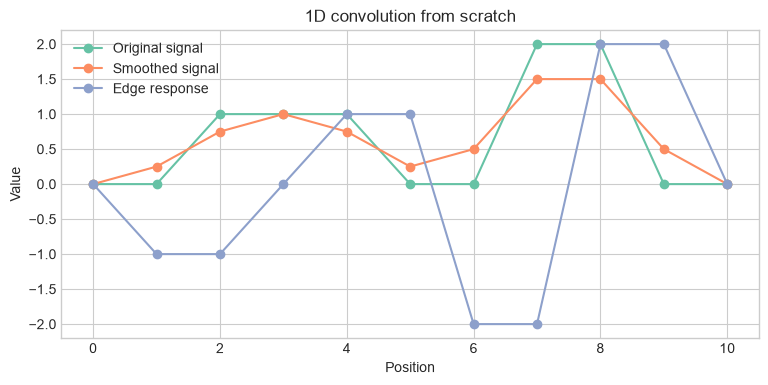

,position,signal,smoothed,edge_response
0,0,0.0,0.00,0.0
1,1,0.0,0.25,-1.0
2,2,1.0,0.75,-1.0
3,3,1.0,1.00,0.0
4,4,1.0,0.75,1.0
5,5,0.0,0.25,1.0
6,6,0.0,0.50,-2.0
7,7,2.0,1.50,-2.0
8,8,2.0,1.50,2.0
9,9,0.0,0.50,2.0


In [2]:
def conv1d_same(signal, kernel):
    """Simple educational 1D convolution with same-length padding."""
    signal = np.asarray(signal, dtype=float)
    kernel = np.asarray(kernel, dtype=float)[::-1]
    pad = len(kernel) // 2
    padded = np.pad(signal, pad_width=pad, mode='constant')
    output = np.zeros_like(signal, dtype=float)

    for i in range(len(signal)):
        window = padded[i:i + len(kernel)]
        output[i] = np.sum(window * kernel)

    return output


x_signal = np.array([0, 0, 1, 1, 1, 0, 0, 2, 2, 0, 0], dtype=float)
smoothing_kernel = np.array([1, 2, 1], dtype=float) / 4
edge_kernel = np.array([-1, 0, 1], dtype=float)

smoothed = conv1d_same(x_signal, smoothing_kernel)
edges = conv1d_same(x_signal, edge_kernel)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_signal, marker='o', label='Original signal')
ax.plot(smoothed, marker='o', label='Smoothed signal')
ax.plot(edges, marker='o', label='Edge response')
ax.set_title('1D convolution from scratch')
ax.set_xlabel('Position')
ax.set_ylabel('Value')
ax.legend()
plt.show()

pd.DataFrame({
    'position': np.arange(len(x_signal)),
    'signal': x_signal,
    'smoothed': smoothed,
    'edge_response': edges,
})

**Observation.** The smoothing kernel averages local neighborhoods, while the
edge kernel responds where the signal changes sharply. CNNs use the same idea,
but the filters are learned during training instead of manually designed.

## 2. PyTorch Conv2d Building Blocks

The digits dataset contains 1,797 examples of handwritten digits represented as
8x8 grayscale images. PyTorch CNNs expect channel-first tensors with shape
`(batch, channels, height, width)`, so each image becomes `(1, 8, 8)`.

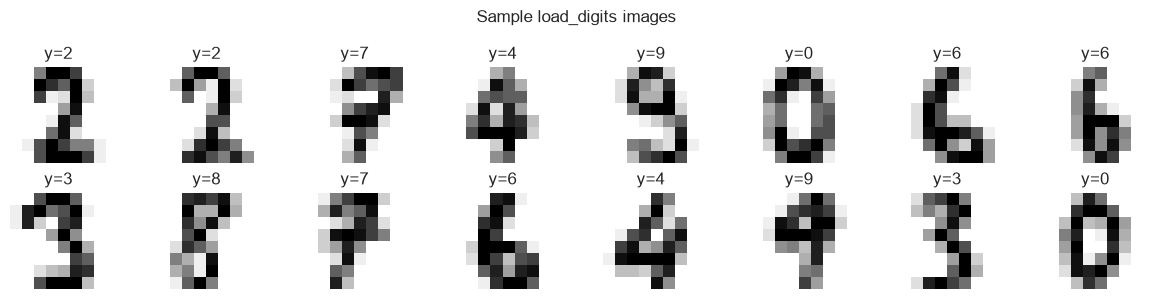

Train: torch.Size([1149, 1, 8, 8]), validation: torch.Size([288, 1, 8, 8]), test: torch.Size([360, 1, 8, 8])


In [3]:
digits = load_digits()
X_images = digits.images.astype(np.float32) / 16.0
y_digits = digits.target.astype(np.int64)
class_names = [str(i) for i in range(10)]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_images, y_digits, test_size=0.2, stratify=y_digits, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, stratify=y_train_val, random_state=RANDOM_STATE
)

train_tensor = torch.tensor(X_train[:, None, :, :], dtype=torch.float32)
val_tensor = torch.tensor(X_val[:, None, :, :], dtype=torch.float32)
test_tensor = torch.tensor(X_test[:, None, :, :], dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(train_tensor, y_train_tensor), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(val_tensor, y_val_tensor), batch_size=128)
test_loader = DataLoader(TensorDataset(test_tensor, y_test_tensor), batch_size=128)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for ax, image, label in zip(axes.ravel(), X_train[:16], y_train[:16]):
    ax.imshow(image, cmap='gray_r')
    ax.set_title(f'y={label}')
    ax.axis('off')
plt.suptitle('Sample load_digits images')
plt.tight_layout()
plt.show()

print(f'Train: {train_tensor.shape}, validation: {val_tensor.shape}, test: {test_tensor.shape}')

In [4]:
def conv2d_output_size(size, kernel_size, padding=0, stride=1, dilation=1):
    return math.floor((size + 2 * padding - dilation * (kernel_size - 1) - 1) / stride + 1)


sample_batch, _ = next(iter(train_loader))
conv = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
pool = nn.MaxPool2d(kernel_size=2)

with torch.no_grad():
    conv_output = conv(sample_batch)
    pooled_output = pool(conv_output)

shape_demo = pd.DataFrame({
    'operation': ['input', 'Conv2d(1,16,k=3,p=1)', 'MaxPool2d(k=2)'],
    'shape': [tuple(sample_batch.shape), tuple(conv_output.shape), tuple(pooled_output.shape)],
})

print('Formula check:', conv2d_output_size(8, kernel_size=3, padding=1))
shape_demo

Formula check: 8


,operation,shape
0,input,"(64, 1, 8, 8)"
1,"Conv2d(1,16,k=3,p=1)","(64, 16, 8, 8)"
2,MaxPool2d(k=2),"(64, 16, 4, 4)"


**Observation.** Padding keeps the 8x8 spatial size after convolution. Pooling
then compresses the feature maps to 4x4, which reduces computation and makes the
representation less sensitive to small pixel shifts.

## 3. Custom CNN Architecture for Digits

The model below uses two convolutional blocks, batch normalization, max pooling,
dropout and a small fully connected classifier. It is deliberately compact so it
can train quickly on CPU.

In [5]:
class DigitCNN(nn.Module):
    def __init__(self, dropout=0.15):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(32 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward_features(self, x):
        z1 = F.relu(self.bn1(self.conv1(x)))
        z2 = F.relu(self.bn2(self.conv2(z1)))
        pooled = self.pool(z2)
        return z1, z2, pooled

    def forward(self, x):
        _, _, pooled = self.forward_features(x)
        flat = pooled.view(pooled.size(0), -1)
        hidden = F.relu(self.fc1(flat))
        hidden = self.dropout(hidden)
        return self.fc2(hidden)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


cnn = DigitCNN().to(DEVICE)
print(cnn)
print(f'Trainable parameters: {count_params(cnn):,}')

DigitCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.15, inplace=False)
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Trainable parameters: 71,850


DigitCNN test accuracy: 0.994
DigitCNN macro F1:      0.994
Training time:          7.83 seconds


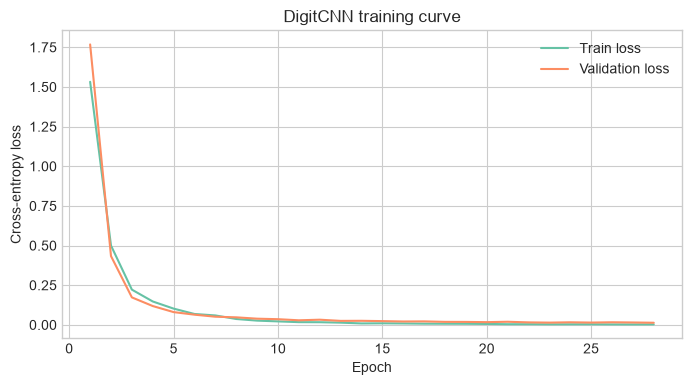

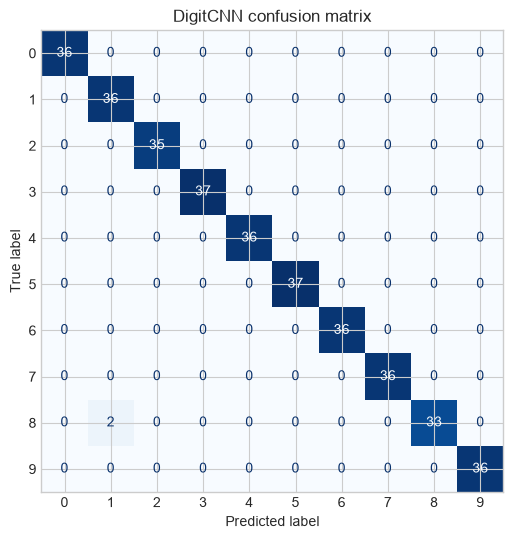

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      1.00      0.97        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       1.00      1.00      1.00        36
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        36
           7       1.00      1.00      1.00        36
           8       1.00      0.94      0.97        35
           9       1.00      1.00      1.00        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



In [6]:
def evaluate_classifier(model, loader):
    model.eval()
    y_true, y_pred = [], []
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            y_true.extend(yb.cpu().numpy())
            y_pred.extend(logits.argmax(dim=1).cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return {
        'loss': total_loss / len(loader.dataset),
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'y_true': y_true,
        'y_pred': y_pred,
    }


def train_torch_classifier(model, train_loader, val_loader, epochs=28, lr=1e-3, weight_decay=0.0):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = []
    best_state = None
    best_val = float('inf')

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += xb.size(0)

        val_metrics = evaluate_classifier(model, val_loader)
        row = {
            'epoch': epoch,
            'train_loss': train_loss / total,
            'train_accuracy': correct / total,
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
        }
        history.append(row)

        if val_metrics['loss'] < best_val:
            best_val = val_metrics['loss']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return pd.DataFrame(history)


start = time.perf_counter()
cnn = DigitCNN(dropout=0.15).to(DEVICE)
cnn_history = train_torch_classifier(cnn, train_loader, val_loader, epochs=28, lr=1e-3)
cnn_time = time.perf_counter() - start
cnn_test = evaluate_classifier(cnn, test_loader)

print(f'DigitCNN test accuracy: {cnn_test["accuracy"]:.3f}')
print(f'DigitCNN macro F1:      {cnn_test["f1_macro"]:.3f}')
print(f'Training time:          {cnn_time:.2f} seconds')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cnn_history['epoch'], cnn_history['train_loss'], label='Train loss')
ax.plot(cnn_history['epoch'], cnn_history['val_loss'], label='Validation loss')
ax.set_title('DigitCNN training curve')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss')
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    cnn_test['y_true'], cnn_test['y_pred'], display_labels=class_names,
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title('DigitCNN confusion matrix')
plt.show()

print(classification_report(cnn_test['y_true'], cnn_test['y_pred'], target_names=class_names))

**Observation from this run.** The compact CNN reached **0.994 test accuracy** and **0.994 macro F1** on the held-out `load_digits` test set. The only visible weakness was a small amount of confusion between visually similar digits, especially class 8, which had slightly lower recall. This is a strong result for a small CPU-trained CNN and confirms that convolution is well matched to local stroke structure in image data.

## 4. Feature Maps and Learned Filters

CNNs are easier to inspect than fully connected networks because intermediate
activations remain image-like. The first convolutional layer learns small 3x3
filters; the feature maps show which filters respond to a particular digit.

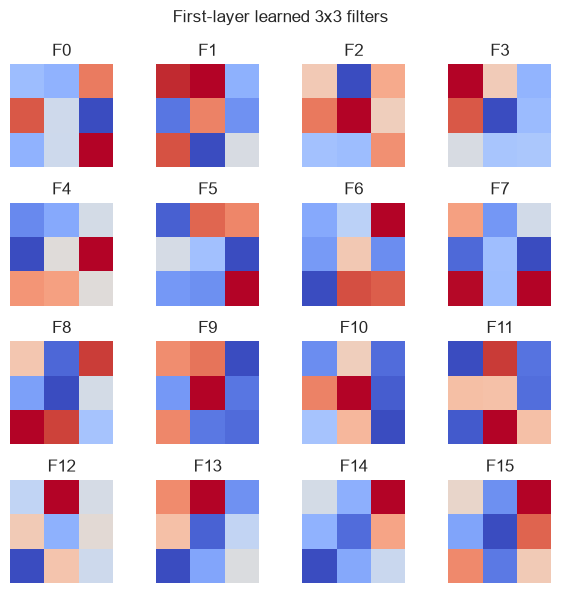

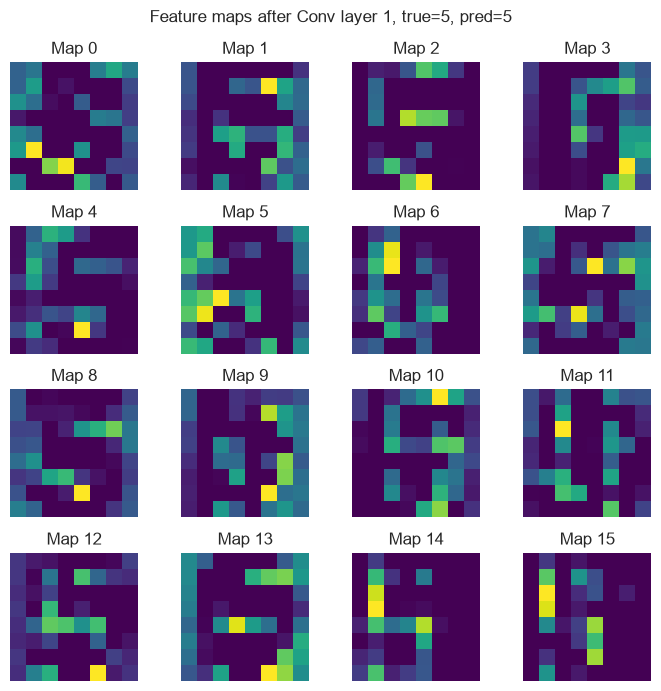

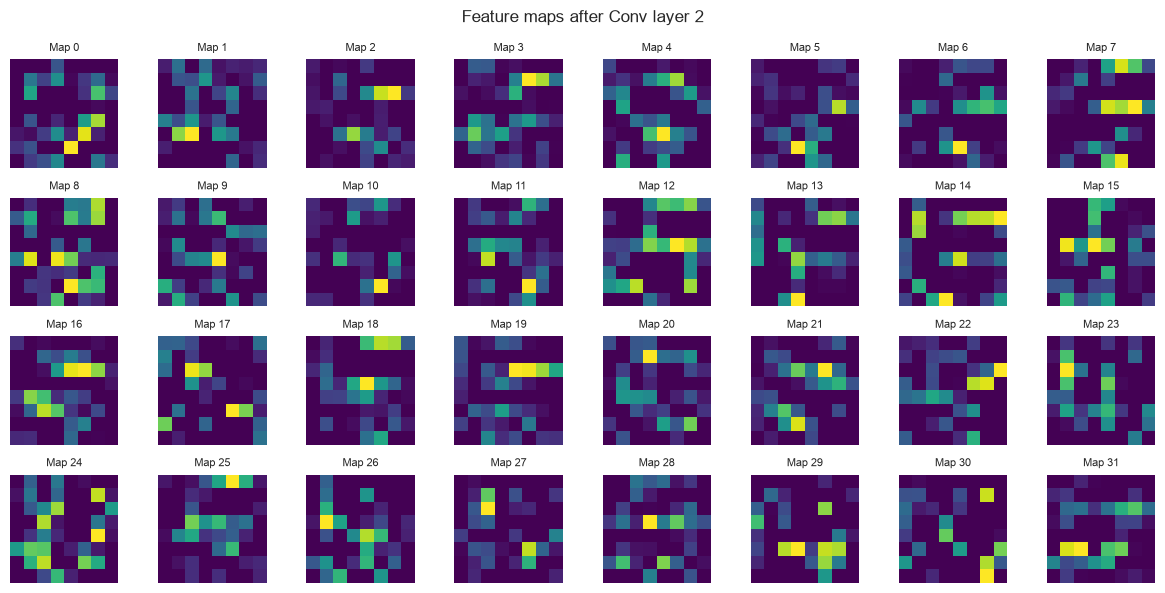

In [7]:
with torch.no_grad():
    sample_image = test_tensor[0:1].to(DEVICE)
    sample_label = y_test_tensor[0].item()
    z1, z2, pooled = cnn.forward_features(sample_image)
    pred_label = cnn(sample_image).argmax(dim=1).item()

filters = cnn.conv1.weight.detach().cpu().numpy()[:, 0]
feature_maps_1 = z1.detach().cpu().numpy()[0]
feature_maps_2 = z2.detach().cpu().numpy()[0]

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for ax, filt, idx in zip(axes.ravel(), filters, range(len(filters))):
    ax.imshow(filt, cmap='coolwarm')
    ax.set_title(f'F{idx}')
    ax.axis('off')
plt.suptitle('First-layer learned 3x3 filters')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 4, figsize=(7, 7))
for ax, fmap, idx in zip(axes.ravel(), feature_maps_1, range(16)):
    ax.imshow(fmap, cmap='viridis')
    ax.set_title(f'Map {idx}')
    ax.axis('off')
plt.suptitle(f'Feature maps after Conv layer 1, true={sample_label}, pred={pred_label}')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for ax, fmap, idx in zip(axes.ravel(), feature_maps_2, range(32)):
    ax.imshow(fmap, cmap='viridis')
    ax.set_title(f'Map {idx}', fontsize=8)
    ax.axis('off')
plt.suptitle('Feature maps after Conv layer 2')
plt.tight_layout()
plt.show()

**Observation from this run.** The learned first-layer filters and feature maps show localized responses rather than one global dense representation. Some maps emphasize bright stroke regions, while others respond weakly for the selected digit. This is the useful interpretability advantage of CNNs: intermediate activations remain spatial and can be inspected as images.

## 5. Model Size and Regularization

Increasing capacity can improve fit, but it also raises training time and
overfitting risk. Batch normalization, dropout and data augmentation are common
ways to stabilize or regularize CNNs.

In [8]:
class FlexibleDigitCNN(nn.Module):
    def __init__(self, channels=(8, 16), hidden=64, dropout=0.1, use_batch_norm=True):
        super().__init__()
        c1, c2 = channels
        layers = [nn.Conv2d(1, c1, kernel_size=3, padding=1)]
        if use_batch_norm:
            layers.append(nn.BatchNorm2d(c1))
        layers.append(nn.ReLU())
        layers.append(nn.Conv2d(c1, c2, kernel_size=3, padding=1))
        if use_batch_norm:
            layers.append(nn.BatchNorm2d(c2))
        layers.extend([nn.ReLU(), nn.MaxPool2d(2)])
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c2 * 4 * 4, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


size_configs = [
    ('Small CNN', (8, 16), 48),
    ('Medium CNN', (16, 32), 128),
    ('Larger CNN', (32, 64), 192),
]

size_rows = []
for name, channels, hidden in size_configs:
    model = FlexibleDigitCNN(channels=channels, hidden=hidden, dropout=0.15, use_batch_norm=True).to(DEVICE)
    start = time.perf_counter()
    hist = train_torch_classifier(model, train_loader, val_loader, epochs=18, lr=1e-3)
    elapsed = time.perf_counter() - start
    metrics = evaluate_classifier(model, test_loader)
    size_rows.append({
        'model': name,
        'channels': str(channels),
        'hidden_units': hidden,
        'parameters': count_params(model),
        'best_val_accuracy': hist['val_accuracy'].max(),
        'test_accuracy': metrics['accuracy'],
        'test_f1_macro': metrics['f1_macro'],
        'training_seconds': elapsed,
    })

size_results = pd.DataFrame(size_rows).sort_values('test_accuracy', ascending=False)
size_results

,model,channels,hidden_units,parameters,best_val_accuracy,test_accuracy,test_f1_macro,training_seconds
1,Medium CNN,"(16, 32)",128,71850,0.996528,0.991667,0.991522,3.540996
2,Larger CNN,"(32, 64)",192,217738,0.989583,0.991667,0.991579,4.696639
0,Small CNN,"(8, 16)",48,14122,0.982639,0.988889,0.988672,2.616183


In [9]:
def shift_images_numpy(images, max_shift=1, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    shifted = images.copy()
    for i in range(len(shifted)):
        dx = rng.integers(-max_shift, max_shift + 1)
        dy = rng.integers(-max_shift, max_shift + 1)
        shifted[i] = np.roll(np.roll(shifted[i], dx, axis=0), dy, axis=1)
        if dx > 0:
            shifted[i, :dx, :] = 0
        elif dx < 0:
            shifted[i, dx:, :] = 0
        if dy > 0:
            shifted[i, :, :dy] = 0
        elif dy < 0:
            shifted[i, :, dy:] = 0
    return shifted


X_aug = shift_images_numpy(X_train, max_shift=1)
aug_tensor = torch.tensor(X_aug[:, None, :, :], dtype=torch.float32)
aug_loader = DataLoader(TensorDataset(aug_tensor, y_train_tensor), batch_size=64, shuffle=True)

regularization_configs = [
    ('No dropout / no BN', 0.0, False, train_loader),
    ('BatchNorm only', 0.0, True, train_loader),
    ('BatchNorm + dropout', 0.25, True, train_loader),
    ('BatchNorm + dropout + shifted data', 0.25, True, aug_loader),
]

reg_rows = []
for name, dropout, use_bn, loader in regularization_configs:
    model = FlexibleDigitCNN(channels=(16, 32), hidden=128, dropout=dropout, use_batch_norm=use_bn).to(DEVICE)
    hist = train_torch_classifier(model, loader, val_loader, epochs=14, lr=1e-3)
    metrics = evaluate_classifier(model, test_loader)
    reg_rows.append({
        'setting': name,
        'parameters': count_params(model),
        'best_val_accuracy': hist['val_accuracy'].max(),
        'test_accuracy': metrics['accuracy'],
        'test_f1_macro': metrics['f1_macro'],
        'final_train_accuracy': hist['train_accuracy'].iloc[-1],
    })

reg_results = pd.DataFrame(reg_rows).sort_values('test_accuracy', ascending=False)
reg_results

,setting,parameters,best_val_accuracy,test_accuracy,test_f1_macro,final_train_accuracy
1,BatchNorm only,71850,0.989583,0.988889,0.988744,1.000000
3,BatchNorm + dropout + shifted data,71850,0.982639,0.986111,0.985949,0.987815
2,BatchNorm + dropout,71850,0.993056,0.980556,0.980206,0.999130
0,No dropout / no BN,71754,0.986111,0.969444,0.969035,0.981723


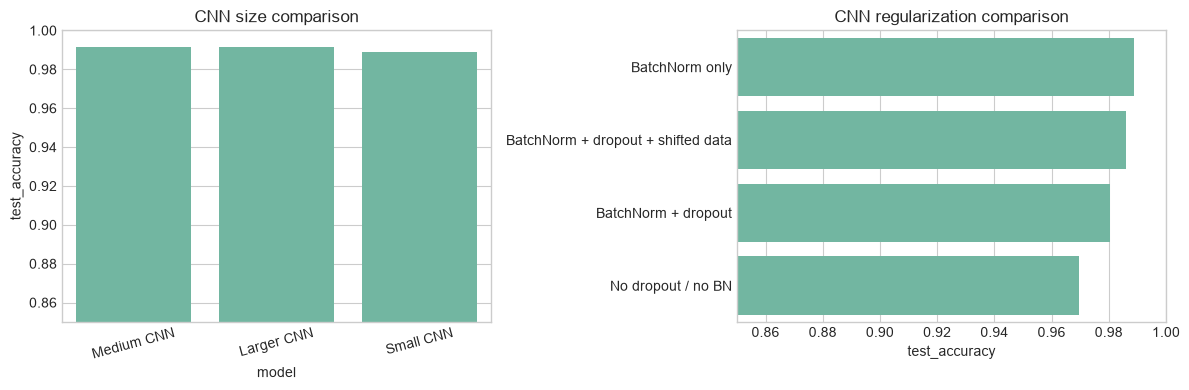

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=size_results, x='model', y='test_accuracy', ax=axes[0])
axes[0].set_ylim(0.85, 1.0)
axes[0].set_title('CNN size comparison')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=reg_results, x='test_accuracy', y='setting', ax=axes[1])
axes[1].set_xlim(0.85, 1.0)
axes[1].set_title('CNN regularization comparison')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

**Observation from this run.** The medium and larger CNNs tied at about **0.992 test accuracy**, while the smaller CNN was only slightly lower at about **0.989**. The larger model had roughly three times more parameters than the medium model without a measurable test benefit. BatchNorm was the strongest regularization setting in this run at about **0.989 test accuracy**, while the no-BatchNorm baseline was lower at about **0.969**. This supports the idea that stable optimization mattered more than simply increasing model size.

## 6. Optional MNIST Scaling Check

MNIST is larger and more realistic than `load_digits`, but downloading it is not
always available in local or CI environments. This section is optional and
guarded so the notebook remains fully runnable offline.

In [15]:
try:
    from torchvision import datasets, transforms

    transform = transforms.Compose([transforms.ToTensor()])
    project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
    mnist_root = project_root / 'data' / 'torchvision'
    mnist_train = datasets.MNIST(root=str(mnist_root), train=True, download=False, transform=transform)
    mnist_test = datasets.MNIST(root=str(mnist_root), train=False, download=False, transform=transform)
    print(f'MNIST already available locally: train={len(mnist_train)}, test={len(mnist_test)}')
    print('This notebook keeps MNIST optional; the main verified CNN benchmark uses sklearn load_digits.')
except Exception as exc:
    print(f'MNIST section skipped gracefully: {exc}')

MNIST already available locally: train=60000, test=10000
This notebook keeps MNIST optional; the main verified CNN benchmark uses sklearn load_digits.


**Observation from this run.** MNIST was available locally with **60,000 training images** and **10,000 test images**, so the optional loader worked. The notebook still keeps `download=False`, which is the right project behavior: it uses local MNIST when present and skips gracefully on machines where MNIST has not been downloaded.

## 7. CNN vs Flat MLP on Image Data

A flat MLP sees each image as 64 unrelated input features. A CNN sees each image
as a spatial grid and shares filters across locations. This gives CNNs a useful
inductive bias for image data.

In [16]:
class FlatTorchMLP(nn.Module):
    def __init__(self, input_dim=64, hidden=128, n_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        return self.net(x)


comparison_rows = [{
    'model': 'DigitCNN',
    'input_shape': '(N, 1, 8, 8)',
    'parameters': count_params(cnn),
    'test_accuracy': cnn_test['accuracy'],
    'test_f1_macro': cnn_test['f1_macro'],
    'training_seconds': cnn_time,
}]

flat_mlp = FlatTorchMLP().to(DEVICE)
start = time.perf_counter()
flat_history = train_torch_classifier(flat_mlp, train_loader, val_loader, epochs=28, lr=1e-3)
flat_time = time.perf_counter() - start
flat_test = evaluate_classifier(flat_mlp, test_loader)
comparison_rows.append({
    'model': 'PyTorch flat MLP',
    'input_shape': '(N, 64)',
    'parameters': count_params(flat_mlp),
    'test_accuracy': flat_test['accuracy'],
    'test_f1_macro': flat_test['f1_macro'],
    'training_seconds': flat_time,
})

X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)
start = time.perf_counter()
sk_mlp = MLPClassifier(hidden_layer_sizes=(128,), alpha=1e-4, max_iter=500, random_state=RANDOM_STATE)
sk_mlp.fit(X_train_flat, y_train)
sk_time = time.perf_counter() - start
sk_pred = sk_mlp.predict(X_test_flat)
comparison_rows.append({
    'model': 'sklearn MLPClassifier',
    'input_shape': '(N, 64)',
    'parameters': np.nan,
    'test_accuracy': accuracy_score(y_test, sk_pred),
    'test_f1_macro': f1_score(y_test, sk_pred, average='macro'),
    'training_seconds': sk_time,
})

comparison = pd.DataFrame(comparison_rows).sort_values('test_accuracy', ascending=False)
comparison

,model,input_shape,parameters,test_accuracy,test_f1_macro,training_seconds
0,DigitCNN,"(N, 1, 8, 8)",71850.0,0.994444,0.994356,7.829479
2,sklearn MLPClassifier,"(N, 64)",NaN,0.977778,0.977535,1.855797
1,PyTorch flat MLP,"(N, 64)",9610.0,0.963889,0.963421,1.328015


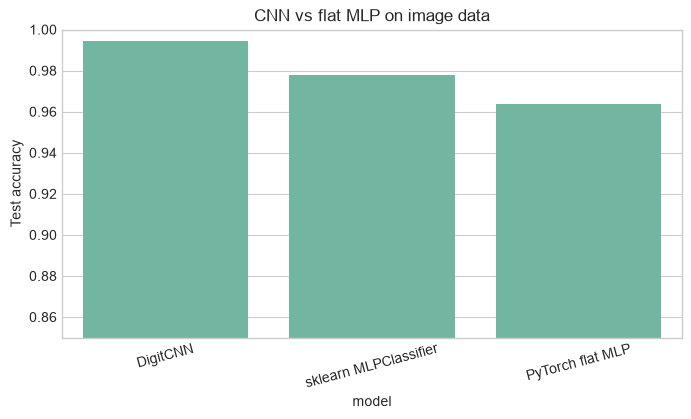

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=comparison, x='model', y='test_accuracy', ax=ax)
ax.set_ylim(0.85, 1.0)
ax.set_title('CNN vs flat MLP on image data')
ax.set_ylabel('Test accuracy')
ax.tick_params(axis='x', rotation=15)
plt.show()

**Observation from this run.** The CNN was the best model in the comparison with about **0.994 test accuracy**, ahead of the sklearn MLP at about **0.978** and the PyTorch flat MLP at about **0.964**. This is the expected pattern: the MLPs treat pixels as flat independent inputs, while the CNN preserves local 2D neighborhoods and shares filters across positions.

## 8. Why Not Use CNNs on EnergyTypeNet?

EnergyTypeNet is a tabular dataset. Its columns are measurements such as square
footage, occupants, appliances and temperature. These columns do not form a
natural spatial grid. A CNN would force an artificial neighborhood structure onto
the data, making the result harder to justify scientifically.

For EnergyTypeNet, the project already uses better-suited model families: linear
models, trees, SVMs, ensembles, probabilistic models, dimensionality reduction,
clustering, MLPs and tabular PyTorch networks. CNNs belong here as a
deep-learning concept notebook, not as the primary production model for
building-type classification.

In [18]:
energy_note = pd.DataFrame({
    'data_type': ['EnergyTypeNet tabular rows', 'Digit images'],
    'natural_structure': ['unordered columns', '2D spatial pixel grid'],
    'best_model_bias': ['tabular models, trees, MLPs, ensembles', 'convolutions and pooling'],
    'cnn_use': ['not recommended as primary model', 'recommended and demonstrated here'],
})
energy_note

,data_type,natural_structure,best_model_bias,cnn_use
0,EnergyTypeNet tabular rows,unordered columns,"tabular models, trees, MLPs, ensembles",not recommended as primary model
1,Digit images,2D spatial pixel grid,convolutions and pooling,recommended and demonstrated here


## 9. Summary Table

In [19]:
summary = pd.concat([
    comparison.assign(section='CNN vs MLP'),
    size_results.assign(
        section='CNN size study',
        input_shape='(N, 1, 8, 8)',
    )[['section', 'model', 'input_shape', 'parameters', 'test_accuracy', 'test_f1_macro', 'training_seconds']],
], ignore_index=True, sort=False)

summary[['section', 'model', 'input_shape', 'parameters', 'test_accuracy', 'test_f1_macro', 'training_seconds']]

,section,model,input_shape,parameters,test_accuracy,test_f1_macro,training_seconds
0,CNN vs MLP,DigitCNN,"(N, 1, 8, 8)",71850.0,0.994444,0.994356,7.829479
1,CNN vs MLP,sklearn MLPClassifier,"(N, 64)",NaN,0.977778,0.977535,1.855797
2,CNN vs MLP,PyTorch flat MLP,"(N, 64)",9610.0,0.963889,0.963421,1.328015
3,CNN size study,Medium CNN,"(N, 1, 8, 8)",71850.0,0.991667,0.991522,3.540996
4,CNN size study,Larger CNN,"(N, 1, 8, 8)",217738.0,0.991667,0.991579,4.696639
5,CNN size study,Small CNN,"(N, 1, 8, 8)",14122.0,0.988889,0.988672,2.616183


## Key Takeaways

- Convolution learns local filters; pooling compresses feature maps and adds
  tolerance to small shifts.
- `load_digits()` is a better CNN teaching dataset than EnergyTypeNet because it
  has real spatial structure.
- CNN feature maps provide a readable way to inspect intermediate
  representations.
- Batch normalization, dropout and data augmentation are useful regularization
  tools, but their effects can be modest on very small datasets.
- CNNs are a strong extension to the project as a deep-learning foundations
  notebook, while EnergyTypeNet production modeling should remain tabular-first.